# Laboratorio #2 — Redes Neuronales Convolucionales (CNN vs. MLP en MNIST)

**CC3092 Deep Learning y Sistemas Inteligentes**

## 0. Imports y configuración

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", DEVICE)

pd.set_option("display.max_columns", None)
%matplotlib inline

Device: mps


## 1. Dataset

In [2]:
# Descarga MNIST en bruto (sin transform) para inspeccionar tipos/rangos originales
raw_train = datasets.MNIST(root="data", train=True, download=True)
raw_test = datasets.MNIST(root="data", train=False, download=True)
len(raw_train), len(raw_test)

0.3%

0.7%

1.0%

1.3%

1.7%

...

97.4%

99.4%

100.0%

100.0%

(60000, 10000)

## 2. Exploración y preparación de los datos

### ¿Cuántas observaciones y cuántas clases tiene el dataset? ¿Están balanceadas?

In [3]:
n_train, n_test = len(raw_train), len(raw_test)
classes = raw_train.classes
print(f"Train: {n_train} imágenes | Test: {n_test} imágenes | Clases: {len(classes)} ({classes})")

train_counts = pd.Series(raw_train.targets.numpy()).value_counts().sort_index()
test_counts = pd.Series(raw_test.targets.numpy()).value_counts().sort_index()
pd.DataFrame({"train": train_counts, "test": test_counts})

Train: 60000 imágenes | Test: 10000 imágenes | Clases: 10 (['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine'])


,train,test
0,5923,980
1,6742,1135
2,5958,1032
3,6131,1010
4,5842,982
5,5421,892
6,5918,958
7,6265,1028
8,5851,974
9,5949,1009


**Hallazgos:** 60,000 imágenes de entrenamiento y 10,000 de test, 10 clases (dígitos 0-9).
Las clases están **razonablemente balanceadas**: cada dígito tiene entre ~9.9k y ~10.7k
observaciones en el set de tamaño 60k, sin ninguna clase dominante ni subrepresentada.

### ¿Cuál es la dimensión de cada imagen y qué rango de valores tienen los píxeles?

In [4]:
img0, label0 = raw_train[0]
arr0 = np.array(img0)
print("Tipo:", type(img0), "| Modo PIL:", img0.mode, "| Tamaño:", img0.size)
print("Shape como array:", arr0.shape, "| dtype:", arr0.dtype)
print("Rango de píxeles: [{}, {}]".format(arr0.min(), arr0.max()))

Tipo: <class 'PIL.Image.Image'> | Modo PIL: L | Tamaño: (28, 28)
Shape como array: (28, 28) | dtype: uint8
Rango de píxeles: [0, 255]


**Hallazgos:** cada imagen es de 28×28 píxeles, en escala de grises (1 canal). Los valores de
píxel son enteros `uint8` en el rango [0, 255].

### ¿Es necesario normalizar los valores de los píxeles?

Sí. Las redes entrenan mejor y de forma más estable con entradas de escala pequeña y centradas
cerca de 0 (gradientes mejor condicionados, convergencia más rápida). Se aplican dos pasos
estándar de `torchvision.transforms`:

1. `ToTensor()`: convierte `uint8 [0,255]` → `float32 [0,1]`.
2. `Normalize(mean=0.1307, std=0.3081)`: estandariza usando la media/desviación estándar
   conocidas de MNIST (calculadas sobre el train set completo), dejando los píxeles
   aproximadamente en media 0 y varianza 1.

In [5]:
MNIST_MEAN, MNIST_STD = 0.1307, 0.3081
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MNIST_MEAN,), (MNIST_STD,)),
])

train_full = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_ds = datasets.MNIST(root="data", train=False, download=True, transform=transform)

x_demo, y_demo = train_full[0]
print("Shape del tensor normalizado:", x_demo.shape, "| rango:", x_demo.min().item(), x_demo.max().item())

Shape del tensor normalizado: torch.Size([1, 28, 28]) | rango: -0.4242129623889923 2.821486711502075


### Visualización de ejemplos

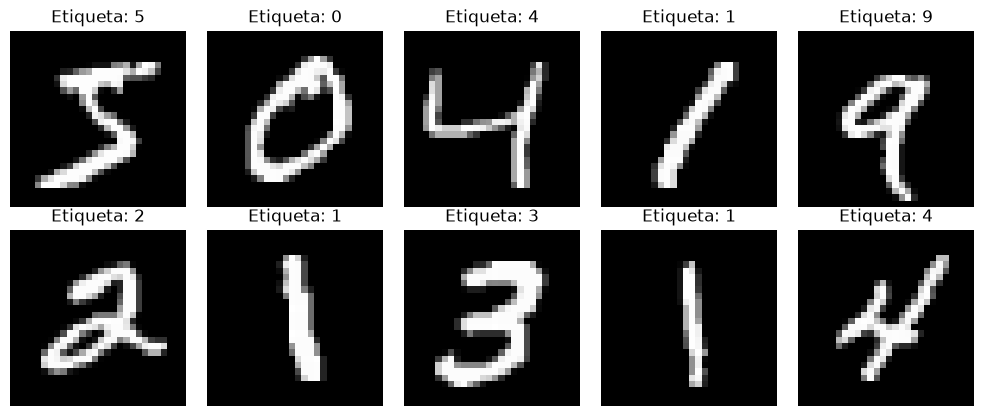

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.2))
for i, ax in enumerate(axes.flat):
    img, label = raw_train[i]
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Etiqueta: {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

### División en entrenamiento y validación

In [7]:
# 90/10 sobre el train set (54,000 / 6,000); el test set (10,000) queda intacto hasta la evaluación final
n_val = int(0.1 * len(train_full))
n_tr = len(train_full) - n_val
generator = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(train_full, [n_tr, n_val], generator=generator)
len(train_ds), len(val_ds), len(test_ds)

(54000, 6000, 10000)

**Regla de aislamiento del test respetada:** `test_ds` no se usa en ninguna decisión de
arquitectura ni de hiperparámetros; solo se evalúa una vez en la sección 5.